In [1]:
from neo4j import GraphDatabase

# Initialize connection to the PuppyGraph.
uri = "bolt://localhost:7687"
username = "puppygraph"
password = "puppygraph123"
driver = GraphDatabase.driver(uri, auth=(username, password))
session = driver.session()

# Get all nodes from the graph.
query = """MATCH (n) WITH n LIMIT 10
MATCH (n)-[r]->(m) RETURN n, r, m
"""
results = session.run(query)

print("All nodes in the graph:")
for record in results:
    node = record["n"]
    print({
        "id": node.element_id,
        "labels": list(node.labels),
        "properties": dict(node._properties)
    })

All nodes in the graph:
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 

In [2]:
import networkx as nx
G = nx.MultiDiGraph()

nodes = list(results.graph()._nodes.values())
for node in nodes:
    G.add_node(node.id, labels=node._labels, properties=node._properties)

rels = list(results.graph()._relationships.values())
for rel in rels:
    G.add_edge(rel.start_node.id, rel.end_node.id, key=rel.id, type=rel.type, properties=rel._properties)

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_64913/2338988782.py:6: DeprecationWarning: `id` is deprecated, use `element_id` instead
  G.add_node(node.id, labels=node._labels, properties=node._properties)
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_64913/2338988782.py:10: DeprecationWarning: `id` is deprecated, use `element_id` instead
  G.add_edge(rel.start_node.id, rel.end_node.id, key=rel.id, type=rel.type, properties=rel._properties)


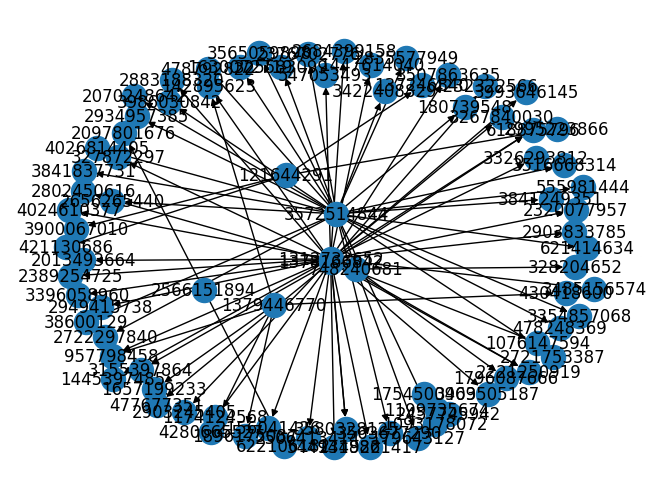

In [3]:
nx.draw(G, with_labels=True)

In [7]:

query = """MATCH (n) WITH n LIMIT 1000
MATCH c=(n)-[*]->(n) RETURN n
"""
# maximum cycle length is 15
cycles = session.run(query)
paths= [record for record in cycles]

In [8]:
paths

[]

In [10]:
# degree of nodes
query = """MATCH (n)-[r]->(m)
RETURN n, count(m) AS degree
"""
degrees = session.run(query)
node_degrees = {record["n"].id: record["degree"] for record in degrees}
node_degrees

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_64913/3274154573.py:6: DeprecationWarning: `id` is deprecated, use `element_id` instead
  node_degrees = {record["n"].id: record["degree"] for record in degrees}


{1379446770: 6,
 1312733652: 27,
 1378166842: 10,
 121644291: 4,
 3572514844: 26,
 2566151894: 2,
 748240681: 3,
 1754500463: 1,
 2457745942: 1,
 1827128233: 6,
 1058547522: 6,
 176108746: 6,
 1413559250: 18,
 2160763229: 6,
 2161351609: 7,
 3351999685: 5,
 3768991265: 9,
 107468567: 8,
 1412922459: 66,
 2669695273: 42,
 2635959607: 84,
 3172832788: 42,
 653053982: 6,
 3806848996: 6,
 3872973734: 6,
 3728081560: 24,
 4202151284: 24,
 1160160945: 72,
 1094727755: 30,
 3011606376: 66,
 183389261: 20,
 2427457886: 8,
 606192101: 30,
 2376686344: 6,
 1010994093: 6,
 1012126926: 6,
 1759919285: 24,
 2202230549: 22,
 4119256265: 12,
 505662400: 7,
 3416555463: 54,
 1043586500: 6,
 2363728690: 3,
 4089049462: 6,
 2248128158: 24,
 2836219600: 5,
 1761172056: 6,
 4214085215: 17,
 3534389070: 2,
 479930689: 6,
 1767471529: 6,
 3587501313: 6,
 3404349020: 6,
 2398089238: 18,
 72319066: 36,
 2430060674: 18,
 138478590: 12,
 3617851503: 6,
 3618984336: 12,
 1324639261: 24,
 576846902: 18,
 37313334